# OpenCourses.AI Colab version

This notebook belongs to **Fundamentos de Transformers** and was published as a public Colab-ready artifact.

Colab is an external free execution option with variable resources. Run the setup cell before executing the rest of the notebook.


In [ ]:
# OpenCourses.AI Colab setup
import os, pathlib, subprocess, sys
REPO_URL = "https://github.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb.git"
BRANCH = "main"
TARGET = pathlib.Path("/content/opencourses/opencourse-fundamentos-de-transformers-d9d23ccb")
TARGET.parent.mkdir(parents=True, exist_ok=True)
if not TARGET.exists():
    print('Downloading the course resources...')
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(TARGET)], check=True)
else:
    print('Using the existing course folder; your local changes are preserved.')
os.environ['COURSE_ROOT'] = str(TARGET)
os.environ['ASSETS_DIR'] = str(TARGET / 'assets')
src_dir = TARGET / 'src'
if src_dir.is_dir() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
notebooks_dir = TARGET / 'notebooks'
if notebooks_dir.exists():
    os.chdir(notebooks_dir)
requirements = TARGET / 'requirements.txt'
if requirements.exists() and requirements.read_text(encoding='utf8').strip():
    print('Checking the course Python dependencies...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements)], check=True)
try:
    from google.colab import output as colab_output
except ImportError:
    pass
else:
    try:
        colab_output.enable_custom_widget_manager()
    except Exception as error:
        print(f'Widget support could not be enabled: {error}')
print(f'COURSE_ROOT={TARGET}')
print('Setup complete. Run the remaining notebook cells from top to bottom.')


<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Fundamentos de Transformers</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 14</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Entrenamiento autoregresivo</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Curso abierto</div>
    </div>
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
    <div><strong>Curso:</strong> Fundamentos de Transformers</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Presentación del notebook

<audio controls style="width: 100%; margin: 8px 0 18px 0;">
  <source src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/audio/notebooks/14_entrenamiento_autoregresivo_intro.mp3" type="audio/mpeg">
  Su navegador no puede reproducir el audio embebido.
</audio>


## Pregunta directriz

> ¿Cómo aprende un mini-GPT a asignar mayor probabilidad al siguiente token observado?

En el notebook 13 construimos la arquitectura completa: embeddings, posiciones, bloques decoder, normalización final y cabeza de lenguaje. En este notebook damos el paso siguiente: ajustar sus parámetros para que los logits produzcan menor pérdida frente a pares autoregresivos $x \rightarrow y$.

La pregunta es central porque construir un modelo no equivale a entrenarlo. El entrenamiento define cómo los errores se convierten en gradientes y cómo esos gradientes modifican embeddings, atención, MLP y cabeza final.


## Objetivos

Al finalizar este notebook, el estudiante debería poder:

1. Construir ventanas autoregresivas $x/y$ a partir de un corpus pequeño tokenizado.
2. Auditar las formas de `x`, `y`, `logits` y la pérdida usada por `cross_entropy`.
3. Ejecutar e interpretar un paso manual `forward -> loss -> backward -> optimizer.step`.
4. Leer curvas de pérdida de entrenamiento y validación, incluyendo una estimación de perplexity.
5. Explicar por qué una pérdida menor indica ajuste al corpus, pero no comprensión general ni utilidad aplicada.


## Marco conceptual

El entrenamiento autoregresivo convierte texto en una tarea supervisada: dado un contexto, el modelo debe asignar alta probabilidad al siguiente token observado. Para lograrlo, el corpus se tokeniza, se convierte en índices y se divide en ventanas de entrada $x$ y objetivos $y$ desplazados una posición.

La cadena conceptual del notebook es:

$$
\text{corpus} \rightarrow \text{tokens} \rightarrow \text{ventanas } x/y \rightarrow \text{logits} \rightarrow \text{cross-entropy} \rightarrow \text{gradientes} \rightarrow \text{actualización} \rightarrow \text{validación}.
$$

La validación es necesaria porque la pérdida de entrenamiento solo mide ajuste sobre ejemplos usados para modificar parámetros. En un corpus pequeño, una pérdida descendente puede significar aprendizaje de regularidades locales, pero también memorización temprana.


## Idea visual: ciclo de entrenamiento

<div style="text-align: center; margin: 12px 0 18px 0;">
  <img src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/figures/14_entrenamiento_autoregresivo.png" alt="Entrenamiento autoregresivo" style="width: min(980px, 98%); height: auto; border: 1px solid #d0d7de; border-radius: 6px;">
</div>

La figura resume el ciclo de entrenamiento: batch autoregresivo, forward pass, logits, pérdida, retropropagación, actualización y evaluación. La lectura importante es que el modelo aprende desde errores locales por token, no desde una evaluación global de la calidad del texto generado.

## Formulación matemática

Sea $B$ el tamaño del batch, $T$ la longitud de contexto, $|\mathcal V|$ el tamaño del vocabulario y $\theta$ el conjunto de parámetros del modelo. Para cada ejemplo $b$ y posición $t$, $x_{b,t}$ es el token de entrada y $y_{b,t}$ es el token objetivo siguiente.

El modelo produce logits:

$$
z_{b,t}=f_\theta(x_{b,\leq t}),
\qquad z_{b,t}\in\mathbb{R}^{|\mathcal V|}.
$$

Esta ecuación se lee así: en cada posición, el modelo mira el contexto causal disponible y produce $|\mathcal V|$ puntajes, uno por cada token posible del vocabulario.

La probabilidad asignada al token objetivo se obtiene aplicando softmax sobre el eje del vocabulario:

$$
p_\theta(y_{b,t}\mid x_{b,\leq t})=
\operatorname{softmax}(z_{b,t})_{y_{b,t}}.
$$

Esta ecuación se lee así: de todos los puntajes producidos, se consulta la probabilidad correspondiente al token que realmente apareció en el corpus.

La pérdida de entrenamiento es la cross-entropy media por token:

$$
\mathcal{L}(\theta)=
-\frac{1}{BT}\sum_{b=1}^{B}\sum_{t=1}^{T}
\log p_\theta(y_{b,t}\mid x_{b,\leq t}).
$$

Esta ecuación se lee así: el modelo recibe una penalización grande cuando asigna baja probabilidad al token observado. PyTorch calcula esta pérdida a partir de logits de forma $(B,T,|\mathcal V|)$ y targets de forma $(B,T)$, aplanándolos conceptualmente a $(B\cdot T,|\mathcal V|)$ y $(B\cdot T)$.

Un paso de optimización actualiza parámetros con el gradiente de la pérdida:

$$
\nabla_\theta \mathcal{L} = \operatorname{backward}(\mathcal{L}),
\qquad
\theta' = \operatorname{AdamWStep}(\theta, \nabla_\theta \mathcal{L}).
$$

Esta ecuación se lee así: `loss.backward()` calcula una señal de cambio para cada parámetro que participó en el forward, y `optimizer.step()` modifica esos parámetros usando AdamW.

La perplexity se define como:

$$
\operatorname{PPL}=\exp(\mathcal{L}).
$$

Esta ecuación se lee así: la perplexity reescala la cross-entropy como una incertidumbre promedio aproximada sobre el siguiente token. No mide comprensión, coherencia global ni conocimiento factual.

## Traducción tensorial

En código, el ciclo de entrenamiento trabaja con cuatro objetos principales:

1. `x`: tensor de entrada con forma `(B,T)`.
2. `y`: tensor objetivo con forma `(B,T)`.
3. `logits`: tensor de puntajes con forma `(B,T,Vocab)`.
4. `loss`: escalar que resume la penalización promedio del batch.

`cross_entropy` compara `logits.reshape(B*T, Vocab)` contra `y.reshape(B*T)`. El paso `loss.backward()` calcula gradientes para los parámetros que participaron en el forward. El paso `optimizer.step()` usa esos gradientes para modificar los parámetros. La validación ejecuta el mismo forward y la misma pérdida, pero sin actualizar pesos.

## Preparación del entorno


In [1]:
from pathlib import Path
import importlib
import sys
import warnings

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import torch

warnings.filterwarnings("ignore", message="Pandas requires version .*", category=UserWarning)
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import fundamentos_transformers.entrenamiento_experimentos as entrenamiento_experimentos
import fundamentos_transformers.visualizacion as visualizacion

entrenamiento_experimentos = importlib.reload(entrenamiento_experimentos)
visualizacion = importlib.reload(visualizacion)

configurar_matplotlib = visualizacion.configurar_matplotlib
mostrar_tablas_en_columnas = visualizacion.mostrar_tablas_en_columnas

configurar_matplotlib()
torch.manual_seed(7)
np.random.seed(7)


## Experimento: corpus, tokens y ventanas autoregresivas

Usaremos un corpus deliberadamente pequeño y repetitivo. Esto permite observar descenso de pérdida en pocas iteraciones, pero también obliga a interpretar los resultados con cautela: el modelo puede ajustarse a patrones locales muy limitados.


In [2]:
resultado_corpus = entrenamiento_experimentos.preparar_corpus_entrenamiento()
corpus = resultado_corpus.corpus
tokens = resultado_corpus.tokens
token_a_id = resultado_corpus.token_a_id
id_a_token = resultado_corpus.id_a_token
ids = resultado_corpus.ids
BLOCK_SIZE = resultado_corpus.block_size
split = resultado_corpus.split
train_ids = resultado_corpus.train_ids
val_ids = resultado_corpus.val_ids
train_data = resultado_corpus.train_data
val_data = resultado_corpus.val_data

mostrar_tablas_en_columnas(
    [
        ("Resumen del corpus", resultado_corpus.resumen),
        ("Particiones", resultado_corpus.particiones),
    ],
    min_width="360px",
)


## Inspección de un batch $x/y$

En una ventana autoregresiva, $y$ es la misma secuencia desplazada una posición respecto a $x$. Esta alineación es la base de la predicción del siguiente token.


In [3]:
resultado_batch = entrenamiento_experimentos.preparar_batch_entrenamiento(train_data, id_a_token)
x_batch = resultado_batch.x_batch
y_batch = resultado_batch.y_batch

mostrar_tablas_en_columnas(
    [
        ("Batch decodificado", resultado_batch.batch),
        ("Alineación x/y", resultado_batch.alineacion),
        ("Formas", resultado_batch.formas),
    ],
    min_width="340px",
)


ejemplo,x decodificado,y decodificado,lectura
0,mezcla contexto.,ezcla contexto.,y es x desplazado una posicion
1,s. atencion mezc,. atencion mezcl,y es x desplazado una posicion
2,kens. atencion m,ens. atencion me,y es x desplazado una posicion
3,ezcla contexto.,zcla contexto. t,y es x desplazado una posicion
posicion t,"x[0,t]","y[0,t]",lectura
0,'m','e',target siguiente respecto al contexto
1,'e','z',target siguiente respecto al contexto
2,'z','c',target siguiente respecto al contexto
3,'c','l',target siguiente respecto al contexto
4,'l','a',target siguiente respecto al contexto


## Paso manual de optimización

Antes de entrenar varias iteraciones, conviene observar un solo paso. En ese paso se calculan logits y pérdida, se propaga el gradiente y luego se actualizan parámetros.

La utilidad `entrenar_pasos` se usará después para repetir este ciclo, pero aquí lo abrimos para ver qué objetos aparecen y qué componentes reciben señal.

In [4]:
CONFIG = {
    "vocab_size": len(token_a_id),
    "block_size": BLOCK_SIZE,
    "n_embd": 24,
    "n_head": 4,
    "n_layer": 1,
    "dropout": 0.0,
}

resultado_paso = entrenamiento_experimentos.preparar_paso_manual(CONFIG, train_data, seed=7)

mostrar_tablas_en_columnas(
    [
        ("Auditoría tensorial", resultado_paso.auditoria),
        ("Ciclo de optimización", resultado_paso.optimizacion),
        ("Gradientes y actualización", resultado_paso.gradientes),
    ],
    min_width="360px",
)


objeto,forma,lectura
x_step,"(8, 16)",batch de entrada
y_step,"(8, 16)",targets desplazados
logits,"(8, 16, 19)","puntajes B,T,V"
loss,escalar,cross-entropy media
paso,que calcula,que cambia
forward,logits y loss,nada
backward,gradientes,parametro.grad
optimizer.step,actualizacion AdamW,parametros
validacion sin gradiente,perdida de referencia,nada
medida,valor,lectura


## Entrenamiento breve y validación

Ahora repetimos varias iteraciones con `entrenar_pasos`. La pérdida de entrenamiento se estima sobre batches de entrenamiento; la de validación se estima sobre batches que no se usan para actualizar parámetros.

La utilidad no introduce una idea nueva: repite el ciclo manual anterior y registra pérdidas cada cierto número de pasos.

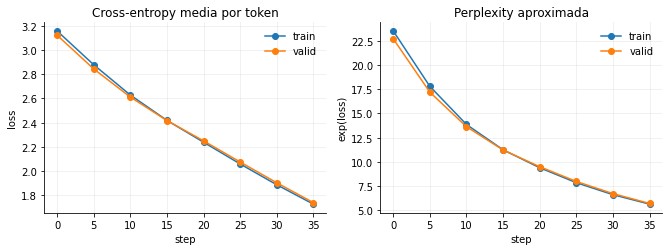

In [5]:
resultado_entrenamiento = entrenamiento_experimentos.preparar_entrenamiento_breve(CONFIG, train_data, val_data, seed=7)
model = resultado_entrenamiento.model
history = resultado_entrenamiento.history

mostrar_tablas_en_columnas(
    [
        ("Historial", resultado_entrenamiento.historial),
        ("Lectura de curvas", resultado_entrenamiento.lectura),
    ],
    min_width="360px",
)

display(resultado_entrenamiento.figura)
plt.close(resultado_entrenamiento.figura)


## Interpretación de las curvas

Si la pérdida de entrenamiento baja, el modelo está asignando mayor probabilidad promedio a los tokens observados en batches de entrenamiento. Si la pérdida de validación también baja, hay evidencia limitada de que parte del ajuste se transfiere a ventanas no usadas directamente para actualizar parámetros.

En este corpus miniatura la lectura debe ser prudente: la repetición facilita que el modelo memorice patrones locales. La perplexity ayuda a leer la escala de incertidumbre promedio aproximada, pero no evalúa coherencia global, verdad factual ni calidad lingüística.

## Verificación de aprendizaje

Cambie una sola variable y compare contra la configuración base: `lr`, `steps` o `block_size`. Registre la evidencia en una tabla y explique el efecto observado.

La comparación debe mantener fijo todo lo demás. Para que la respuesta sea válida, conecte decisión, evidencia y cautela: cambio en `train_loss`, cambio en `val_loss`, cambio en `ppl` o cambio en la brecha `val-train`. Si cambia varias cosas al tiempo, no podrá atribuir el cambio de pérdida a una decisión concreta.

In [6]:
resultado_comparacion = entrenamiento_experimentos.preparar_comparacion_entrenamiento(CONFIG, ids, split, train_ids)

mostrar_tablas_en_columnas(
    [
        ("Comparación controlada", resultado_comparacion.comparacion),
        ("Lectura esperada", resultado_comparacion.lectura),
    ],
    min_width="360px",
)


## Análisis crítico

**Qué ocurrió.** El modelo redujo la pérdida sobre un corpus pequeño y produjo curvas de entrenamiento y validación calculables.

**Por qué ocurrió.** La cross-entropy transforma errores de predicción por token en gradientes. Esos gradientes actualizan embeddings, proyecciones de atención, MLP, normalizaciones y cabeza de lenguaje para asignar más probabilidad a patrones observados.

**Qué no se puede concluir.** No se puede afirmar comprensión del lenguaje, capacidad generativa robusta ni generalización amplia. Con un corpus pequeño y repetitivo, una pérdida baja puede reflejar memorización de regularidades locales.

**Lectura operacional.** El paso manual muestra que el aprendizaje no es una llamada mágica: `forward` produce logits, `loss` resume errores por token, `backward` calcula gradientes y `AdamW step` cambia parámetros. La validación mide la misma pérdida sin permitir actualización.

## Síntesis

La cadena operacional del notebook es:

$$
\text{corpus} \rightarrow \text{tokens} \rightarrow x,y \rightarrow z=f_\theta(x) \rightarrow \mathcal{L}(z,y) \rightarrow \nabla_\theta\mathcal{L} \rightarrow \theta' \rightarrow \text{validación}.
$$

Esta cadena se lee así: el texto se convierte en pares autoregresivos, el modelo produce logits, la pérdida mide el error por token, el gradiente actualiza parámetros y la validación estima si el ajuste se mantiene fuera de los batches de actualización.

<div style="border-left: 4px solid #1f2a44; padding: 10px 14px; background: #f6f8fa; margin-top: 10px;">
La idea central es que entrenar un Transformer no es ejecutar una caja negra: es repetir un ciclo local de predicción, penalización, gradiente y actualización bajo una partición explícita de datos.
</div>

## Preguntas de discusión

1. ¿Por qué $y$ debe estar desplazado una posición respecto a $x$ en entrenamiento autoregresivo?
2. ¿Por qué `cross_entropy` recibe logits y no probabilidades calculadas manualmente?
3. ¿Qué indica una brecha creciente entre pérdida de entrenamiento y pérdida de validación?
4. ¿Por qué una perplexity menor no demuestra comprensión lingüística general?
5. ¿Qué evidencia adicional necesitaríamos antes de analizar generación de texto?


## Continuidad

Ya tenemos un mini-GPT entrenado durante pocas iteraciones sobre un corpus controlado. El siguiente notebook usa el ciclo de generación para convertir logits en tokens, comparar estrategias de muestreo e interpretar límites: repetición, incoherencia y sobreinterpretación de salidas.
